# TA Tutorial Session — IITREICT-AIML-2604 — Decision Trees, Gini Impurity, and Confusion Matrix Evaluation

Academic Session 25 - Decision Tree Implementation, Academic Session 26 - Classification Evaluation: The Confusion Matrix,

**Assignment:** Decision Tree
Implementation - Objective, Assignment: Decision Tree Implementation -
**Subjective, Assignment:** Classification Evaluation: The Confusion Matrix -
**Objective, Assignment:** Classification Evaluation: The Confusion Matrix - Subjective

**Agenda**

1. A quick topic summary to refresh what was covered in the faculty session.
2. 5 objective questions to test your understanding — vote in the chat.
3. 1 scenario-based practice question — these are directly aligned to your assessments, so
pay close attention.
4. An open Q&A block where you can ask anything from the main session or today.

**Context Setting**

- **Link to main session:** The faculty sessions covered how decision trees use the Gini impurity index to build rule-based classifiers, and then introduced the confusion matrix as the foundational tool for evaluating any classification model's performance — including the decision trees we just built.
- **Why this matters for assessments:** Both the objective and subjective assignments directly test your ability to compute Gini impurity by hand, implement a decision tree in
`scikit-learn`, and construct a confusion matrix with correct `TP`, `TN`, `FP`, and `FN` counts.

# Section 1: Topic-wise Summary

**Topic 1: Decision Tree — Rule-Based Algorithm vs. Learning-Based Algorithms**

**1. What is a Decision Tree?**

A Decision Tree is a **supervised machine learning algorithm** used for *classification* and **regression**.

It makes decisions using a sequence of IF–ELSE rules.

**Think of it as a flowchart**.

                 Study Hours >= 4 ?

                    /         \
                  No           Yes
                 /              \
         Attend Class?         PASS
            /     \
          No      Yes
         FAIL     PASS

The model simply follows the rules until it reaches the final decision.

**Why is it Called a Tree?**

Because it looks like an upside-down tree.

               Root

             Study Hours

            /          \

         <4            >=4

       Attend?         PASS

      /      \
   FAIL      PASS

**Rule-Based Algorithm**

- A Decision Tree does not learn equations. Instead, it creates rules.

**Example**:
IF Hours >= 4

      PASS

ELSE

      FAIL

This is exactly what a Decision Tree learns from data.

In [2]:
hours = 4
if hours >= 4:
    print("PASS")
else:
    print("FAIL")

PASS


**Why is it Called Rule-Based?**

Because every prediction follows a **sequence of IF–ELSE conditions**.

**Example:**

IF Age > 18

      IF Salary > 50000

              Approve Loan

      ELSE

              Reject Loan

ELSE

      Reject Loan

There are no mathematical equations involved during prediction—only rules.

**Learning-Based Algorithms**

Examples:

- Logistic Regression
- Support Vector Machine (SVM)
- Neural Networks

These algorithms do **not create IF–ELSE rules**. Instead, they **learn weights (parameters)** from **data**.

**Example**:

Prediction = W₁ × X₁ + W₂ × X₂ + Bias

**Decision Tree vs Logistic Regression**

| Decision Tree           | Logistic Regression                     |
| ----------------------- | --------------------------------------- |
| Rule-based              | Learning-based                          |
| Uses IF–ELSE rules      | Uses mathematical equation              |
| Easy to understand      | Harder to interpret                     |
| No weight parameters    | Learns weights                          |
| No optimizer            | Uses an optimizer|
| Good for small datasets | Performs better with larger datasets    |


**Python Example (Simple Rule)**

In [4]:
hours = 5

if hours >= 4:
    print("PASS")
else:
    print("FAIL")

# same logic a Decision Tree eventually learns automatically.

PASS


**Machine Learning Example**

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

data = {
    "Hours": [2, 3, 5, 6],
    "Result": [0, 0, 1, 1]   # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)

X = df[["Hours"]]
y = df["Result"]

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

prediction = model.predict([[5]])

print("Prediction:", prediction[0])

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**How Does the Model Think?**

Training Data -> Find Best Rule -> Hours >=4 ? -> Build Decision Tree -> Predict New Student

**Advantages of Decision Trees**
- Easy to understand
- Easy to visualize
- No feature scaling required
- Works for classification and regression
- Can handle numerical and categorical data
- Easy to explain predictions

**Disadvantages**
- Can overfit if the tree is too deep
- Sensitive to noisy data
- Small changes in data can change the tree
- Usually less accurate than ensemble methods like Random Forest

**Remember:**

**Decision Tree** = Rules + Questions + Decisions

Whereas:

**Logistic Regression** = Equation + Weights + Optimization

**Topic 2: Anatomy of a Decision Tree — Nodes, Branches, and Leaf Nodes**

**1. What is the Anatomy of a Decision Tree?**

Just like a human body has different parts (head, arms, legs), a Decision Tree also has different components.

**These components are:**

- Root Node
- Internal Node
- Branch
- Leaf Node

Together they form the complete Decision Tree.

**Real-Life Example**

Suppose a bank wants to decide whether to approve a loan.

                 Income > 50,000 ?

                    /          \
                  No            Yes
                 /               \
          Reject Loan      Credit Score > 700 ?

                             /           \
                           No             Yes
                          Reject        Approve

**2. Root Node**

The Root Node is the **first node of the tree**. It is the **starting point** for every prediction.

In our example:

Income > 50,000 ? is the Root Node.

**Why is it called the Root?**

Just like the root of a tree is the **starting point**, every prediction in a **Decision Tree starts from the Root Node**.

               ROOT NODE

          Income > 50,000 ?
**Example**

Student Prediction

Hours Studied >= 4 ?

        /      \
      No        Yes

Here,

Hours **Studied >= 4 is the Root Node**.

**3. Internal Node**

An Internal Node is any decision node between the root and the leaf.

It asks another question.

**Example**

Hours >=4 ?

       No

Attendance >=80% ?

      /        \

Here,

Attendance >=80% ? **is an Internal Node**.

**Simple Definition:** An Internal Node performs another test before reaching the final answer.

**4. Branch**

A Branch connects one node to another.

Every branch represents the outcome of a question.

Usually,

Yes  or No

or

True, False

**Example**

          Hours >=4 ?

          /        \

       No           Yes

Left branch = No

Right branch = Yes

**5. Leaf Node**

A Leaf Node is the final node. No more questions are asked.

The prediction is made here.

**Example**

Hours >=4 ?

      /       \

   FAIL      PASS

Here, FAIL PASS are Leaf Nodes.

**Why is it called a Leaf ?**

Because it is at the end of the tree, just like leaves are at the ends of branches.

**Complete Decision Tree**
                  Root Node

            Hours Studied >=4 ?

              /            \

           No              Yes
            │                │
            ▼                ▼

      Internal Node       Leaf Node

 Attendance >=80% ?         PASS

      /        \

    FAIL      PASS

 Leaf Node   Leaf Node

**6. Pure Node**

A node is Pure when all samples belong to the same class.

**Example**

| Student | Result |
| ------- | ------ |
| A       | Pass   |
| B       | Pass   |
| C       | Pass   |
Every student belongs to Pass. This is a **Pure Node**.

**Example**: PASS PASS PASS Only one class exists. So, Pure Node

**Gini Value**

Pure Node

Gini = 0

The tutorial also notes that a pure node has a Gini impurity of 0, **because there is no uncertainty about the class**.

**7. Impure Node**

An Impure Node contains multiple classes.

**Example**

| Student | Result |
| ------- | ------ |
| A       | Pass   |
| B       | Fail   |
| C       | Pass   |

Here, Both PASS FAIL exist. Therefore, this is an **Impure Node.**

Example: PASS FAIL PASS Mixed classes  -> **Impure Node**

In [6]:
# Python Example
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

data = {
    "Hours":[2,3,5,6],
    "Attendance":[60,70,90,95],
    "Result":[0,0,1,1]
}

df = pd.DataFrame(data)

X = df[["Hours","Attendance"]]
y = df["Result"]

model = DecisionTreeClassifier(max_depth=2)

model.fit(X,y)

print("Tree Created Successfully")

Tree Created Successfully


**Visualizing the Tree :**

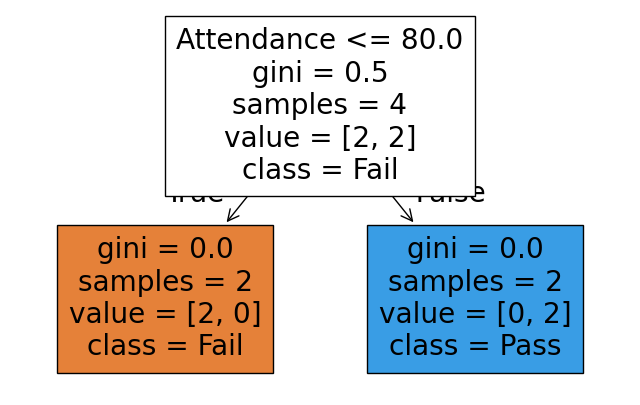

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plot_tree(
    model,
    feature_names=["Hours","Attendance"],
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

**Confusing Root Node and Internal Node**
- The Root Node is always the first node.
- Internal Nodes come after the root.
- Thinking every Leaf Node is Pure
- In practice, most leaf nodes are pure, but if the tree stops early (e.g., because of max_depth), a leaf node can still contain mixed classes.
- Assuming branches store data
- Branches only represent the outcome of a decision (e.g., Yes/No or True/False); the data remains in the nodes.

### Topic 3: Gini Impurity – How a Decision Tree Chooses the Best Split

**What Problem Does Gini Solve?**

Suppose we have **two features**:

| Hours Studied | Attend Class | Result |
| ------------- | ------------ | ------ |
| 2             | No           | Fail   |
| 3             | No           | Fail   |
| 5             | Yes          | Pass   |
| 6             | Yes          | Pass   |

Which feature should become the Root Node?

Should the tree ask

Hours >=4 ?

or

Attend Class?

**How does the computer decide?**

It cannot guess. It needs a mathematical measure.

That measure is called **Gini Impurity**

**Simple Definition:** Gini Impurity **measures how mixed the classes are in a node**. OR Gini tells us **how impure (mixed) a node is**.

**Real-Life Example**

Imagine a basket.

**Basket A -**
🍎
🍎
🍎
🍎
🍎
Only apples.

Very easy to identify. This basket is Pure.

**Basket B -**
🍎 🍌 🍎 🍌 🍌

Mixed fruits. Confusing. This basket is Impure. Exactly the same happens in Decision Trees.

**What Does Gini Measure?**

Suppose a node contains

- PASS
- PASS
- PASS
- PASS

There is **no confusion. Gini = 0**

Now suppose

- PASS
- FAIL
- PASS
- FAIL

Now the node is mixed. **Decision becomes difficult**.

**Gini becomes larger**.

**Important Rule**

- **Lower Gini** -> Better Split -> Pure Node

- **Higher Gini** -> Mixed Classes -> Bad Split

Gini Formula

The tutorial gives the following formula:

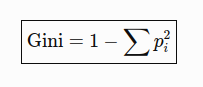

where

pi = Probability of each class

For binary classification

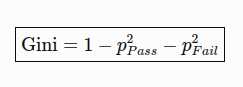

**Manual Example**

Suppose a node has

| Result |
| ------ |
| Pass   |
| Pass   |
| Pass   |
| Fail   |

Total = 4,
Pass = 3,
Fail = 1

**Step 1:**

Probability of Pass

P(Pass)= 3/4 = 0.75

Probability of Fail

P(Fail)= 1/4 = =0.25


**Step 2: Square them**

(0.75)2 = 0.5625
(0.25)2 = 0.0625

**Step 3 Add**

0.5625 + 0.0625 = 0.625

**Step 4: Subtract from 1**

Gini = 1 − 0.625

     Gini = 0.375 (Somewhat mixed)
	​

**Important Values**
| Gini | Meaning                   |
| ---- | ------------------------- |
| 0    | Perfectly Pure            |
| 0.1  | Very Good                 |
| 0.2  | Good                      |
| 0.3  | Moderate                  |
| 0.5  | Maximum impurity (Binary) |


**Python Example (Manual Gini)**

In [2]:
import numpy as np

labels = np.array(["Pass","Pass","Pass","Fail"])

classes, counts = np.unique(labels, return_counts=True)

probabilities = counts / len(labels)

gini = 1 - np.sum(probabilities ** 2)

print("Classes      :", classes)
print("Counts       :", counts)
print("Probabilities:", probabilities)
print("Gini         :", round(gini,4))

Classes      : ['Fail' 'Pass']
Counts       : [1 3]
Probabilities: [0.25 0.75]
Gini         : 0.375


**Function to Calculate Gini**

In [3]:
import numpy as np

def gini(labels):

    labels = np.array(labels)

    classes, counts = np.unique(labels, return_counts=True)

    probabilities = counts / len(labels)

    return 1 - np.sum(probabilities ** 2)


data = ["Pass","Pass","Pass","Fail"]

print(gini(data))

0.375


**Why Do We Need Weighted Gini?**

Suppose we split a node.

We get

**Left Node:** PASS FAIL FAIL

**Right Node :** PASS PASS PASS PASS PASS

**Can we compare only one branch?**

No.

We must consider both branches.

Therefore, **Decision Tree calculates Weighted Gini.**

**Weighted Gini Formula**

**Meaning**

- **Large** branches should **contribute** **more**.

- **Small** branches **contribute** **less**.

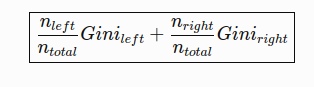

**Example:** Suppose

Left - 4 samples, Gini = 0.25

Right - 6 samples, Gini = 0

**Weighted Gini** = 4/10(0.25) + 6/10(0) = 0.1

Very good split.

**Which Split is Better?**

Suppose

**Feature A** - Weighted Gini = 0.18

**Feature B** - Weighted Gini = 0.42

Decision Tree chooses : **Feature A**

**Because 0.18 < 0.42**

**Simple Rule:** Lower Weighted Gini -> Better Feature -> Root Node

**Confusing Gini with Accuracy**
- Gini is used during training to choose the best split.
- Accuracy is used after training to evaluate the model.
- Thinking Higher Gini is Better
- The goal is always to minimize Gini. Lower Gini means purer nodes.

**Confusing Branch Gini with Weighted Gini**
- A branch has its own Gini value.
- The decision tree compares weighted Gini across all branches to select the best split.

### Topic 4: Overfitting, Underfitting, and Choosing max_depth

**1. Underfitting**

**Definition**: A model is too simple and cannot learn the data properly.

**Example**
Hours >= 4 ?

       Yes → PASS
       No  → FAIL

The tree stops too early and may misclassify many students.

**Characteristics**
- Low training accuracy
- Low testing accuracy
- Model misses important patterns

**2. Overfitting**

**Definition**: A model becomes too complex and memorizes the training data instead of learning general patterns.

**Example**

Hours >=4 ?

      Yes

Attendance >80% ?

Age >20 ?

Homework >5 ?

The tree keeps adding unnecessary branches until almost every training sample is classified correctly.

**Characteristics**
- Very high training accuracy (often 100%)
- Poor testing accuracy
- Does not generalize well to new data

**3. Best Fit (Optimal Model)**

A good Decision Tree is neither too shallow nor too deep.

Underfitting  ←──── Best Fit ────→ Overfitting

The goal is to achieve good performance on unseen data, not just perfect training accuracy.

**4. What is max_depth?**

max_depth specifies the maximum number of levels allowed in a Decision Tree.

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)

Commom values
| max_depth  | Result                          |
| ---------- | ------------------------------- |
| 1          | Very simple tree (may underfit) |
| 3–5        | Usually a good balance          |
| Very large | May overfit                     |


In [11]:
# Python example
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

**Parameter Explanation**
- criterion="gini" → Uses Gini Impurity for splitting.
- max_depth=3 → Limits the tree to 3 levels.
- random_state=42 → Makes results reproducible.

**Memory Trick**

- Small Tree  → Underfitting

- Balanced Tree → Best Fit

- Deep Tree → Overfitting

**Remember**: Increase max_depth carefully. A deeper tree is not always a better tree.

### Topic 5: Confusion Matrix – Evaluating a Classification Model

**1. What is a Confusion Matrix?**

A Confusion Matrix is a table used to evaluate the performance of a classification model.

It **compares**:

- Actual values
- Predicted values

2. Confusion Matrix Structure
| Actual \ Predicted | Negative | Positive |
| ------------------ | -------- | -------- |
| **Negative**       | TN       | FP       |
| **Positive**       | FN       | TP       |

**Rows** = Actual Class
**Columns** = Predicted Class

**3. Understanding TP, TN, FP, FN**

Suppose:

**Positive** = Pass,
**Negative** = Fail

| Term                    | Meaning                      |
| ----------------------- | ---------------------------- |
| **TP (True Positive)**  | Actual Pass → Predicted Pass |
| **TN (True Negative)**  | Actual Fail → Predicted Fail |
| **FP (False Positive)** | Actual Fail → Predicted Pass |
| **FN (False Negative)** | Actual Pass → Predicted Fail |


**4. Example**
| Student | Actual | Predicted |
| ------- | ------ | --------- |
| A       | Pass   | Pass      |
| B       | Fail   | Fail      |
| C       | Pass   | Fail      |
| D       | Fail   | Pass      |

**Result**:

TP = 1,
TN = 1,
FP = 1,
FN = 1

**5. Accuracy Formula**

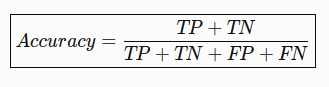

**Example**:

**TP** = 5, **TN** = 3, **FP** = 1, **FN** = 1

**Accuracy** = 5+3 / 5+3+1+1

  = 8/10

  =0.8

  =80%

**6. Python Example**

In [4]:
# python example
from sklearn.metrics import confusion_matrix, accuracy_score

actual = [1, 1, 1, 0, 0]
predicted = [1, 0, 1, 0, 1]

cm = confusion_matrix(actual, predicted)
acc = accuracy_score(actual, predicted)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[1 1]
 [1 2]]
Accuracy: 0.6


**7. Why Not Use Accuracy Alone?**

**Suppose**:

- 90 students passed
- 10 students failed

A model predicts Pass for everyone.

Accuracy: 90/100 = 90%

Looks good, but the model **never identifies a Fail student**.

This is **why the Confusion Matrix is more informative** **than accuracy alone**, especially for **imbalanced datasets**.

# Section 2: Objective Questions

### Question 1

A DevOps engineer runs the following code on an imbalanced dataset of 10 learners,
where the "model" is hard-coded to always predict pass without doing any real learning:
actual = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0])
predicted = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
accuracy_score(actual, predicted)

What value does this expression evaluate to? **Type: SCQ** Options:
1. 1.0, since the two arrays have the same length.
2. 0.5, since half of the hard-coded values happen to be 1.
3. 0.1, since only one label differs between the two arrays.
4. 0.9, since 9 of the 10 predictions match the actual labels.

<details><summary><b>Answer & explanation</b></summary>

**Correct: 4.** 0.9, since 9 of the 10 predictions match the actual labels.
**Explanation:** The actual array has nine 1s and one 0, while predicted is all 1s; nine of the
ten positions match and only the last position (actual 0, predicted 1) is a mismatch.

- A: Incorrect — equal array length is a precondition for comparison, not the accuracy
value itself; it has nothing to do with how many positions match.
- B: Incorrect — accuracy is not "half the values are 1"; it compares corresponding
positions between the two arrays, not the raw count of 1s in one array alone.
- C: Incorrect — 0.1 is the fraction of positions that are wrong (one mismatch out of ten),
which is the inverse of accuracy, not accuracy itself.
- D: **Correct** — nine of the ten predictions match the actual labels, so
accuracy_score(actual, predicted) = 9 / 10 = 0.9.

### Question 2
A senior data analyst has computed TP = 5, TN = 3, FP = 1, FN = 1 for a balanced 10-
learner dataset and now wants to rigorously compare two different candidate models before
choosing one to ship. Which of the following statements are correct? (Select all that apply.)
Type: MSQ Options:
1. Precision and recall are computed independently of the confusion matrix and have no
relationship to the F1 score.
2. Accuracy from these counts equals (TP + TN) / (TP + TN + FP + FN) = 0.80, matching
accuracy_score on the same columns.
3. F1 score is simply a restatement of accuracy and adds no information beyond what
accuracy already shows.
4. Two models should never be compared directly by accuracy alone, or by raw confusion
matrix counts

<details><summary><b>Answer & explanation</b></summary>

**Correct: 2.** Accuracy from these counts equals (TP + TN) / (TP + TN + FP + FN) = 0.80,
matching accuracy_score on the same columns., **4.** Two models should never be compared
directly by accuracy alone, or by raw confusion matrix counts.
**Explanation:** Substituting TP = 5, TN = 3, FP = 1, FN = 1 gives accuracy = (5 + 3) / (5 + 3
+ 1 + 1) = 0.80, and models are compared using the derived F1 score rather than raw
accuracy or raw cell counts.
- A: Incorrect — precision and recall are the two metrics that feed into F1 score and are
always discussed together, so they are directly related to F1, not independent of it.
- B: **Correct** — (5 + 3) / (5 + 3 + 1 + 1) = 8 / 10 = 0.80, matching the value produced by
calling accuracy_score directly on the same actual/predicted columns.
- C: Incorrect — F1 score is specifically designed to expose weaknesses that accuracy
hides, such as a model being effectively "useless" on one class despite a high accuracy
figure; it is not a mere restatement of accuracy.
- D: **Correct** — two models are never compared directly by accuracy alone, nor by raw
confusion matrix cell counts, because accuracy can't capture imbalance effects and the
matrix alone doesn't reduce to one comparable score.

### Question 3
A senior data analyst evaluates a fitted decision tree on the same 8-student dataset used to build the tree, following the standard accuracy formula that applies regardless of which algorithm produced the predictions. The tree correctly predicts 7 out of the 8 pass/fail labels, with only one actual "pass" incorrectly predicted as "fail." What accuracy should the analyst report? **Type: SCQ Options:**
1. 75% of the instances were classified correctly.
2. 87.5% of the instances were classified correctly.
3. 90% of the instances were classified correctly.
4. 62.5% of the instances were classified correctly.

<details><summary><b>Answer & explanation</b></summary>

**Correct:** 2. 87.5% of the instances were classified correctly.
Explanation: Accuracy is the number of correct predictions divided by the total number of
instances, so with 7 correct predictions out of 8 total instances, accuracy = 7 / 8 = 0.875,
or 87.5%.
- A: Incorrect — 75% would correspond to 6 correct out of 8, but the tree actually got 7 of
the 8 predictions right.
- **B:** **Correct** — 7 correct out of 8 total instances gives exactly 0.875, or 87.5%.
- C: Incorrect — 90% is a plausible-looking round number but does not correspond to any
exact count of correct predictions out of 8 total.
- D: Incorrect — 62.5% would correspond to only 5 correct out of 8, which understates
how many predictions the tree actually got right.

### Question 4

A product manager reviews a trained decision tree from the study-hours example, where
the root split is "hours of study ≥ 4," and the right branch (hours ≥ 4) is a pure node with
class = Pass. The product manager wants to know what the tree predicts for a new student
who studied 5 hours. Type: SCQ Options:
1. Fail, because the tree must check recovery-class attendance before hours, regardless of
the study-hours value.
2. Fail, because 5 hours falls below the maximum of 6 hours seen in the training data.
3. Pass, because 5 ≥ 4 routes the instance to the pure right branch, which is classified as
Pass.
4. Pass, but only after also checking whether the student attended the recovery class.

<details><summary><b>Answer & explanation</b></summary>

**Correct**: 3. Pass, because 5 ≥ 4 routes the instance to the pure right branch, which is
classified as Pass.
Explanation: -
- A) Wrong — the root condition is checked first, not the recovery-class
attendance; attendance is only used as a second-level split on the left (hours < 4) branch.
- B) Wrong — there is no rule about a "maximum" of 6 hours; the split condition is a
simple threshold ("hours ≥ 4"), and 5 clearly satisfies it.
- C) **Correct** — the root split tests "hours ≥ 4" first, and since 5 ≥ 4, the instance is
routed to the right branch, which is already a pure node with class = Pass; no further
checks are needed.
- D) Wrong — the right branch (hours ≥ 4) is already pure, so the tree does not need to
evaluate the recovery-class feature at all here; that second split only applies within the
left (hours < 4) branch.

### Question 5
A backend engineer is building a dashboard to visualize a binary classifier's confusion
matrix. Following the convention used for structuring the matrix, how should the rows and
columns be labeled? **Type: SCQ Options**:
1. Rows represent predicted class; columns represent actual class.
2. Rows and columns both represent the predicted class, at different thresholds.
3. Rows represent the actual class; columns represent the predicted class.
4. Rows represent instance IDs; columns represent class probabilities.

<details><summary><b>Answer & explanation</b></summary>

**Correct**: **3**. Rows represent the actual class; columns represent the predicted class.
Explanation: For binary classification, the confusion matrix is a two-row, two-column table
where rows represent the actual class and columns represent the predicted class, with each
cell holding a count of how many instances fall into that actual/predicted combination.
- A: Incorrect — this reverses the convention; rows are the actual class and columns are
the predicted class, not the other way around.
- B: Incorrect — rows and columns represent two conceptually different things, actual
outcome versus predicted outcome, not the same thing measured twice at different
thresholds.
- C: **Correct** — rows represent the actual class (e.g., actual fail, actual pass) and columns
represent the predicted class (e.g., predicted fail, predicted pass).
- D: Incorrect — the matrix is built purely from comparing actual and predicted class
labels; it does not track instance identifiers or continuous probabilities, and other input
features used to generate the predictions play no role in it.

# Section 3: Scenario-based Practice Questions

**Question1 :** A junior ML engineer has been asked to reproduce, from scratch, the Gini-impurity-based split-selection logic that a decision tree library uses internally — without calling any
decision-tree classifier class directly — so the team can verify by hand why "hours of study ≥ 4" was chosen as the root split over "attended recovery class" for a small study-hours data set.

**Constraints & Requirements:**
- Use only Python with NumPy and pandas (no scikit-learn calls for the impurity computation itself).
- Implement a function that computes the Gini impurity of any array of class labels, returning 0 when no labels are passed in.
- Implement a second function that, given a DataFrame and a boolean split condition, computes the Gini impurity of each resulting branch and the overall weighted Gini of the split.
- Use these two functions to compare the candidate root splits "hours >= 4" and "attended == 1" on the full 8-row data set below, and report which one should be
chosen as the root condition and why

**Submission Format Example**


In [ ]:
import pandas as pd
import numpy as np
def genie(labels):
# TODO: compute the Gini impurity of the given array of labels.
# Return 0 immediately if there are no labels.
pass
def weighted_genie_after_split(df, condition):
# TODO: split df into left (~condition) and right (condition) subsets,
# compute the Gini impurity of each subset's 'result' column,
# and combine them into a single weighted Gini score.
pass
def choose_best_root_split(df):
# TODO: compare the "hours >= 4" split against the "attended == 1" split
# using weighted_genie_after_split, and return a description of which
# split has the lower weighted Gini and should be chosen as the root.
pass
if __name__ == "__main__":
df = pd.DataFrame({
'hours': [2, 3, 2, 3, 5, 6, 5, 6],
'attended': [0, 0, 1, 1, 0, 1, 1, 0],
'result': ['Fail', 'Fail', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass']
})
print(choose_best_root_split(df))

In [1]:
import pandas as pd
import numpy as np


def gini(labels):
    labels = np.array(labels)
    n = len(labels)

    if n == 0:
        return 0

    impurity = 1

    for cls in np.unique(labels):
        p = np.sum(labels == cls) / n
        impurity -= p ** 2

    return impurity


def weighted_gini_after_split(df, condition):
    left = df[~condition]
    right = df[condition]

    n = len(df)

    g_left = gini(left['result'])
    g_right = gini(right['result'])

    weighted = (len(left) / n) * g_left + (len(right) / n) * g_right

    return g_left, g_right, weighted


def choose_best_root_split(df):

    _, _, w_hours = weighted_gini_after_split(
        df,
        df['hours'] >= 4
    )

    _, _, w_attended = weighted_gini_after_split(
        df,
        df['attended'] == 1
    )

    if w_hours < w_attended:
        return (
            f"Choose 'hours >= 4' as the root split "
            f"(Weighted Gini = {w_hours:.4f}) over "
            f"'attended == 1' (Weighted Gini = {w_attended:.4f})."
        )

    else:
        return (
            f"Choose 'attended == 1' as the root split "
            f"(Weighted Gini = {w_attended:.4f}) over "
            f"'hours >= 4' (Weighted Gini = {w_hours:.4f})."
        )


if __name__ == "__main__":

    df = pd.DataFrame({
        'hours': [2, 3, 2, 3, 5, 6, 5, 6],
        'attended': [0, 0, 1, 1, 0, 1, 1, 0],
        'result': ['Fail', 'Fail', 'Fail', 'Pass',
                   'Pass', 'Pass', 'Pass', 'Pass']
    })

    print(choose_best_root_split(df))

Choose 'hours >= 4' as the root split (Weighted Gini = 0.1875) over 'attended == 1' (Weighted Gini = 0.4375).


**Question 2:** Build and Visualize a Decision Tree


A school wants to predict whether a student will Pass or Fail based on the number of study hours and attendance percentage.

Create the following dataset:
| Hours | Attendance | Result |
| ----- | ---------- | ------ |
| 2     | 60         | Fail   |
| 3     | 65         | Fail   |
| 4     | 70         | Pass   |
| 5     | 80         | Pass   |
| 6     | 90         | Pass   |
| 2     | 75         | Fail   |
| 5     | 85         | Pass   |
| 3     | 68         | Fail   |

**Requirements**
- Create a Pandas DataFrame.
- Separate features (Hours, Attendance) and target (Result).
- Encode the target labels (Pass = 1, Fail = 0).
- Train a Decision Tree using:
         `criterion='gini'`
        `max_depth=2`
        `random_state=42`
- Predict the result for a student with:
      `Hours = 4`
      `Attendance = 78`
- Display the Decision Tree using `plot_tree()`.
- Explain why the tree may not always choose Hours as the root feature.

In [ ]:
# ============================================================
# Decision Tree Classification Example (Complete Solution)
# ============================================================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ------------------------------------------------------------
# Step 1: Create the Dataset
# ------------------------------------------------------------
data = {
    "Hours": [2, 3, 4, 5, 6, 2, 5, 3],
    "Attendance": [60, 65, 70, 80, 90, 75, 85, 68],
    "Result": ["Fail", "Fail", "Pass", "Pass",
               "Pass", "Fail", "Pass", "Fail"]
}

df = pd.DataFrame(data)

print("="*50)
print("Original Dataset")
print("="*50)
print(df)

# ------------------------------------------------------------
# Step 2: Encode Target Labels
# Pass = 1
# Fail = 0
# ------------------------------------------------------------
df["Result"] = df["Result"].map({
    "Fail": 0,
    "Pass": 1
})

print("\n")
print("="*50)
print("Dataset After Encoding")
print("="*50)
print(df)

# ------------------------------------------------------------
# Step 3: Separate Features and Target
# ------------------------------------------------------------
X = df[["Hours", "Attendance"]]
y = df["Result"]

print("\nFeatures (X)")
print(X)

print("\nTarget (y)")
print(y)

# ------------------------------------------------------------
# Step 4: Train the Decision Tree
# ------------------------------------------------------------
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=2,
    random_state=42
)

model.fit(X, y)

print("\n")
print("="*50)
print("Model Trained Successfully")
print("="*50)

# ------------------------------------------------------------
# Step 5: Predict for a New Student
# Hours = 4
# Attendance = 78
# ------------------------------------------------------------
new_student = [[4, 78]]

prediction = model.predict(new_student)

print("\nNew Student")
print("Hours      :", new_student[0][0])
print("Attendance :", new_student[0][1])

if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

# ------------------------------------------------------------
# Step 6: Display Feature Importance
# ------------------------------------------------------------
print("\n")
print("="*50)
print("Feature Importance")
print("="*50)

for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature:12s}: {importance:.3f}")

# ------------------------------------------------------------
# Step 7: Visualize the Decision Tree
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier")
plt.show()

# ------------------------------------------------------------
# Step 8: Explanation
# ------------------------------------------------------------
print("\n")
print("="*50)
print("Explanation")
print("="*50)
print("1. The Decision Tree examines all available features.")
print("2. It selects the feature that gives the lowest Gini Impurity.")
print("3. The selected feature becomes the Root Node.")
print("4. The tree continues splitting until it reaches the maximum depth")
print("   or the nodes become sufficiently pure.")
print("5. The new student's features are passed through the tree")
print("   to obtain the final prediction.")

# ------------------------------------------------------------
# Answer to Theory Question
# ------------------------------------------------------------
print("\n")
print("="*50)
print("Theory Question")
print("="*50)
print("Q. Why may the Decision Tree not always choose 'Hours' as the Root Node?")
print("\nAnswer:")
print("A Decision Tree evaluates all available features and computes the")
print("weighted Gini impurity for each possible split.")
print("The feature with the lowest weighted Gini impurity is selected as")
print("the Root Node. Therefore, if 'Attendance' separates the classes")
print("better than 'Hours', the tree will choose 'Attendance' as the")
print("Root Node.")

**Question 3: Calculate Gini Impurity Manually**

A Decision Tree receives the following class labels at a node:
- Pass
- Pass
- Fail
- Pass
- Fail
- Fail
- Pass
- Pass

**Requirements**

Write a Python program (without using Scikit-learn) to:
- Count the number of each class.
- Compute the probability of each class.
- Calculate the Gini Impurity using its formula.	​
- Print:
 1. Number of Pass samples
 2. Number of Fail samples
 3. Probability of each class
 4. Final Gini Impurity
- State whether the node is Pure or Impure.

- Modify the function so it works for any number of classes, not just Pass/Fail.

In [14]:
# ============================================================
# Solution: Calculate Gini Impurity Manually
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Step 1: Given Class Labels
# ------------------------------------------------------------
labels = np.array([
    "Pass",
    "Pass",
    "Fail",
    "Pass",
    "Fail",
    "Fail",
    "Pass",
    "Pass"
])

print("=" * 60)
print("Given Labels")
print("=" * 60)
print(labels)

# ------------------------------------------------------------
# Step 2: Count Each Class
# ------------------------------------------------------------
classes, counts = np.unique(labels, return_counts=True)

print("\n" + "=" * 60)
print("Class Counts")
print("=" * 60)

for cls, cnt in zip(classes, counts):
    print(f"{cls:5s} : {cnt}")

# ------------------------------------------------------------
# Step 3: Calculate Probability of Each Class
# ------------------------------------------------------------
total_samples = len(labels)
probabilities = counts / total_samples

print("\n" + "=" * 60)
print("Class Probabilities")
print("=" * 60)

for cls, prob in zip(classes, probabilities):
    print(f"P({cls}) = {prob:.4f}")

# ------------------------------------------------------------
# Step 4: Calculate Gini Impurity
# Formula:
# Gini = 1 - Σ(pi²)
# ------------------------------------------------------------
gini = 1 - np.sum(probabilities ** 2)

print("\n" + "=" * 60)
print("Gini Impurity Calculation")
print("=" * 60)

print("Σ(pi²) =", round(np.sum(probabilities ** 2), 4))
print("Gini   =", round(gini, 4))

# ------------------------------------------------------------
# Step 5: Determine Whether the Node is Pure or Impure
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Node Type")
print("=" * 60)

if gini == 0:
    print("The node is PURE.")
else:
    print("The node is IMPURE.")

# ------------------------------------------------------------
# Bonus: Generic Function (Works for Any Number of Classes)
# ------------------------------------------------------------
def calculate_gini(labels):
    labels = np.array(labels)

    classes, counts = np.unique(labels, return_counts=True)
    probabilities = counts / len(labels)
    gini = 1 - np.sum(probabilities ** 2)

    return classes, counts, probabilities, gini

# ------------------------------------------------------------
# Test the Generic Function
# ------------------------------------------------------------
classes, counts, probabilities, gini = calculate_gini(labels)

print("\n" + "=" * 60)
print("Using Generic Gini Function")
print("=" * 60)

for cls, cnt, prob in zip(classes, counts, probabilities):
    print(f"{cls:5s} -> Count = {cnt}, Probability = {prob:.4f}")

print("\nFinal Gini Impurity =", round(gini, 4))

if gini == 0:
    print("Node Status : PURE")
else:
    print("Node Status : IMPURE")

Given Labels
['Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass']

Class Counts
Fail  : 3
Pass  : 5

Class Probabilities
P(Fail) = 0.3750
P(Pass) = 0.6250

Gini Impurity Calculation
Σ(pi²) = 0.5312
Gini   = 0.4688

Node Type
The node is IMPURE.

Using Generic Gini Function
Fail  -> Count = 3, Probability = 0.3750
Pass  -> Count = 5, Probability = 0.6250

Final Gini Impurity = 0.4688
Node Status : IMPURE


**Question 4: Confusion Matrix Analysis**

A machine learning model predicts whether an email is Spam (1) or Not Spam (0).

In [ ]:
actual = [1,1,0,1,0,0,1,0,1,0]

predicted = [1,0,0,1,1,0,1,0,0,0]

**Requirements**

Using Scikit-learn:

- Compute the Confusion Matrix.
- Calculate: Accuracy, Precision, Recall, F1 Score, Identify the values of: TP, TN, FP, FN
- Explain: Which type of error (FP or FN) occurs more often?
If this model is used for spam email detection, which error is more critical and why?

In [15]:
# ============================================================
# Solution: Confusion Matrix Analysis
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Step 1: Actual and Predicted Labels
# ------------------------------------------------------------
actual = [1, 1, 0, 1, 0, 0, 1, 0, 1, 0]

predicted = [1, 0, 0, 1, 1, 0, 1, 0, 0, 0]

print("=" * 60)
print("Actual Labels")
print("=" * 60)
print(actual)

print("\n" + "=" * 60)
print("Predicted Labels")
print("=" * 60)
print(predicted)

# ------------------------------------------------------------
# Step 2: Compute Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(actual, predicted)

print("\n" + "=" * 60)
print("Confusion Matrix")
print("=" * 60)
print(cm)

# ------------------------------------------------------------
# Step 3: Extract TN, FP, FN, TP
# ------------------------------------------------------------
TN, FP, FN, TP = cm.ravel()

print("\n" + "=" * 60)
print("Confusion Matrix Components")
print("=" * 60)
print("True Positive (TP) :", TP)
print("True Negative (TN) :", TN)
print("False Positive(FP) :", FP)
print("False Negative(FN) :", FN)

# ------------------------------------------------------------
# Step 4: Calculate Evaluation Metrics
# ------------------------------------------------------------
accuracy = accuracy_score(actual, predicted)
precision = precision_score(actual, predicted)
recall = recall_score(actual, predicted)
f1 = f1_score(actual, predicted)

print("\n" + "=" * 60)
print("Evaluation Metrics")
print("=" * 60)
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")

# ------------------------------------------------------------
# Step 5: Determine Which Error Occurs More Often
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Error Analysis")
print("=" * 60)

if FP > FN:
    print(f"False Positives occur more often ({FP} > {FN})")
elif FN > FP:
    print(f"False Negatives occur more often ({FN} > {FP})")
else:
    print(f"False Positives and False Negatives occur equally ({FP} each)")

# ------------------------------------------------------------
# Step 6: Theory Question
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Theory Question")
print("=" * 60)
print("Q. If this model is used for Spam Email Detection,")
print("   which error is more critical and why?\n")

print("Answer:")
print("False Negatives (FN) are usually more critical.")
print("A False Negative means a spam email is incorrectly")
print("classified as a normal email and reaches the user's inbox.")
print("This may expose users to phishing attacks, malware,")
print("or unwanted advertisements.")
print("Although False Positives can hide legitimate emails")
print("inside the spam folder, missing dangerous spam is")
print("generally considered the more serious error.")

# ------------------------------------------------------------
# Step 7: Summary
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"Accuracy  = {accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall    = {recall:.2f}")
print(f"F1 Score  = {f1:.2f}")

Actual Labels
[1, 1, 0, 1, 0, 0, 1, 0, 1, 0]

Predicted Labels
[1, 0, 0, 1, 1, 0, 1, 0, 0, 0]

Confusion Matrix
[[4 1]
 [2 3]]

Confusion Matrix Components
True Positive (TP) : 3
True Negative (TN) : 4
False Positive(FP) : 1
False Negative(FN) : 2

Evaluation Metrics
Accuracy  : 0.70
Precision : 0.75
Recall    : 0.60
F1 Score  : 0.67

Error Analysis
False Negatives occur more often (2 > 1)

Theory Question
Q. If this model is used for Spam Email Detection,
   which error is more critical and why?

Answer:
False Negatives (FN) are usually more critical.
A False Negative means a spam email is incorrectly
classified as a normal email and reaches the user's inbox.
This may expose users to phishing attacks, malware,
or unwanted advertisements.
Although False Positives can hide legitimate emails
inside the spam folder, missing dangerous spam is
generally considered the more serious error.

Summary
TP = 3
TN = 4
FP = 1
FN = 2
Accuracy  = 0.70
Precision = 0.75
Recall    = 0.60
F1 Score  = 0.67

**Answer the below questions**

**Question:** A Decision Tree Model A has 100% training accuracy but 72% testing accuracy. Another Model B has 95% training accuracy and 93% testing accuracy.

1. Which model would you choose for deployment?
2. Which model is likely overfitting?
3. How can the max_depth parameter help improve the model?
4. Why is testing accuracy more important than training accuracy?